In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('FXU','MU'), 
         ('FXR','CSCO'), 
         ('FXO','INTC'), 
         ('FXU','MU'), 
         ('FXR', 'CSCO'),
         ('FXO', 'INTC'), 
         ('FXU','MU'), 
         ('FXR', 'CSCO'), 
         ('FXO','INTC')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, 

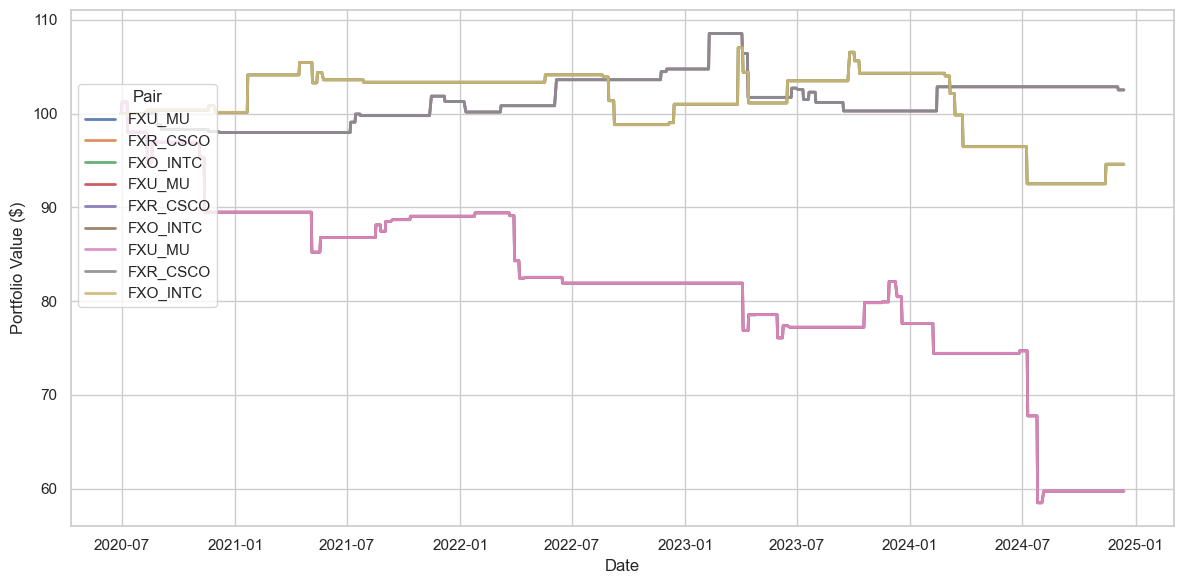

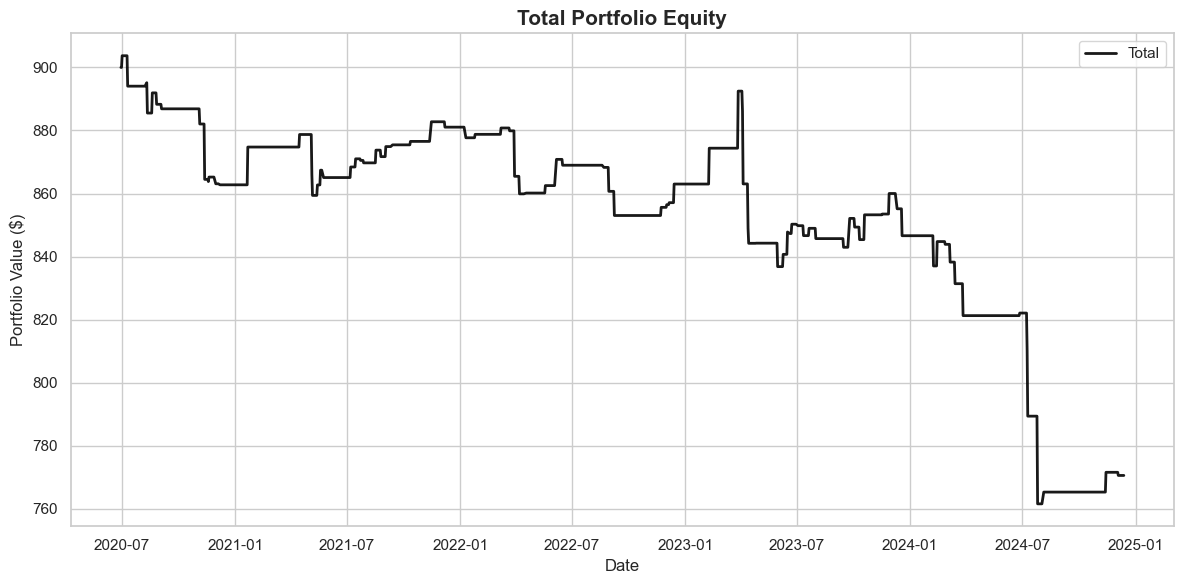

Summary
FXU_MU: Final Value = $59.72, Total Return = -40.28%, Trades = 35
FXR_CSCO: Final Value = $102.53, Total Return = 2.53%, Trades = 25
FXO_INTC: Final Value = $94.60, Total Return = -5.40%, Trades = 28
FXU_MU: Final Value = $59.72, Total Return = -40.28%, Trades = 35
FXR_CSCO: Final Value = $102.53, Total Return = 2.53%, Trades = 25
FXO_INTC: Final Value = $94.60, Total Return = -5.40%, Trades = 28
FXU_MU: Final Value = $59.72, Total Return = -40.28%, Trades = 35
FXR_CSCO: Final Value = $102.53, Total Return = 2.53%, Trades = 25
FXO_INTC: Final Value = $94.60, Total Return = -5.40%, Trades = 28

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $770.55
Total Return:            -14.38%

Sharpe Ratios
FXU_MU: Sharpe Ratio = -1.02
FXR_CSCO: Sharpe Ratio = 0.16
FXO_INTC: Sharpe Ratio = -0.18
FXU_MU: Sharpe Ratio = -1.02
FXR_CSCO: Sharpe Ratio = 0.16
FXO_INTC: Sharpe Ratio = -0.18
FXU_MU: Sharpe Ratio = -1.02
FXR_CSCO: Sharpe Ratio = 0.16
FXO_INTC: 

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)